In [3]:
!pip install -q kaggle
#installing kaggle first

In [4]:
from google.colab import files
files.upload()
#connecting google colab with kaggle , so we can load our dataset easily

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"ahmedalicasper","key":"620591550e2e1a569d79a3d137fa9381"}'}

In [6]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
#This code is used to securely set up your Kaggle API credentials—typically inside a Jupyter Notebook or Google Colab environment.

In [7]:
!kaggle datasets download -d aryashah2k/breast-ultrasound-images-dataset
#loading our dataset after connecting between colab - kaggle

Dataset URL: https://www.kaggle.com/datasets/aryashah2k/breast-ultrasound-images-dataset
License(s): CC0-1.0
100% 195M/195M [00:01<00:00, 196MB/s]



In [8]:
!unzip -q breast-ultrasound-images-dataset.zip -d breast_ultrasound_data
#unziping the dataset

In [9]:
import os

# Check the subfolders inside the dataset
dataset_path = 'breast_ultrasound_data/Dataset_BUSI_with_GT'
if os.path.exists(dataset_path):
    print("Folders found:", os.listdir(dataset_path))
else:
    print("Directory structure might slightly differ. Check current files:")
    !ls breast_ultrasound_data/

Folders found: ['benign', 'malignant', 'normal']


In [10]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('breast_ultrasound_data'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

breast_ultrasound_data/Dataset_BUSI_with_GT/benign/benign (382).png
breast_ultrasound_data/Dataset_BUSI_with_GT/benign/benign (289).png
breast_ultrasound_data/Dataset_BUSI_with_GT/benign/benign (377)_mask.png
breast_ultrasound_data/Dataset_BUSI_with_GT/benign/benign (281)_mask.png
breast_ultrasound_data/Dataset_BUSI_with_GT/benign/benign (343).png
breast_ultrasound_data/Dataset_BUSI_with_GT/benign/benign (355).png
breast_ultrasound_data/Dataset_BUSI_with_GT/benign/benign (263)_mask.png
breast_ultrasound_data/Dataset_BUSI_with_GT/benign/benign (240)_mask.png
breast_ultrasound_data/Dataset_BUSI_with_GT/benign/benign (204).png
breast_ultrasound_data/Dataset_BUSI_with_GT/benign/benign (313).png
breast_ultrasound_data/Dataset_BUSI_with_GT/benign/benign (288).png
breast_ultrasound_data/Dataset_BUSI_with_GT/benign/benign (172).png
breast_ultrasound_data/Dataset_BUSI_with_GT/benign/benign (47)_mask.png
breast_ultrasound_data/Dataset_BUSI_with_GT/benign/benign (87)_mask.png
breast_ultrasound_da

In [11]:
base_path = "breast_ultrasound_data/Dataset_BUSI_with_GT/"
categories = ["benign","malignant", "normal"]

In [12]:
data = []

for category in categories:
    category_path = os.path.join(base_path, category)
    files = sorted(os.listdir(category_path))

    for file in files:
        if "_mask" in file:
            continue

        img_path = os.path.join(category_path, file)
        mask_path = os.path.join(category_path, file.replace(".png", "_mask.png"))

        data.append([img_path, mask_path, category])

df = pd.DataFrame(data, columns=["Image_Path", "Mask_Path", "Label"])
#setting up our dataframe that we are going to use

In [13]:
df.head()


,Image_Path,Mask_Path,Label
0,breast_ultrasound_data/Dataset_BUSI_with_GT/be...,breast_ultrasound_data/Dataset_BUSI_with_GT/be...,benign
1,breast_ultrasound_data/Dataset_BUSI_with_GT/be...,breast_ultrasound_data/Dataset_BUSI_with_GT/be...,benign
2,breast_ultrasound_data/Dataset_BUSI_with_GT/be...,breast_ultrasound_data/Dataset_BUSI_with_GT/be...,benign
3,breast_ultrasound_data/Dataset_BUSI_with_GT/be...,breast_ultrasound_data/Dataset_BUSI_with_GT/be...,benign
4,breast_ultrasound_data/Dataset_BUSI_with_GT/be...,breast_ultrasound_data/Dataset_BUSI_with_GT/be...,benign


In [14]:
df.duplicated().sum()

np.int64(0)

In [15]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 780 entries, 0 to 779
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Image_Path  780 non-null    object
 1   Mask_Path   780 non-null    object
 2   Label       780 non-null    object
dtypes: object(3)
memory usage: 18.4+ KB


In [16]:
df['Label'].unique()


array(['benign', 'malignant', 'normal'], dtype=object)

In [17]:
df['Label'].value_counts()


,count
Label,
benign,437
malignant,210
normal,133


/tmp/ipykernel_525/800116102.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="Label", palette="viridis", ax=ax)


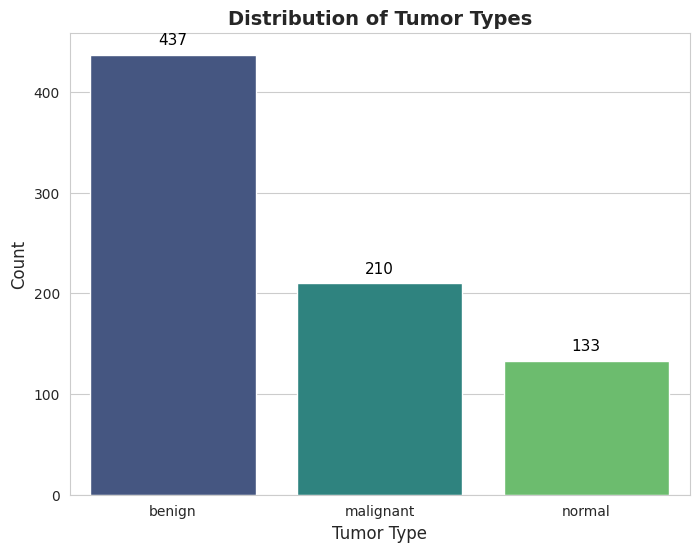

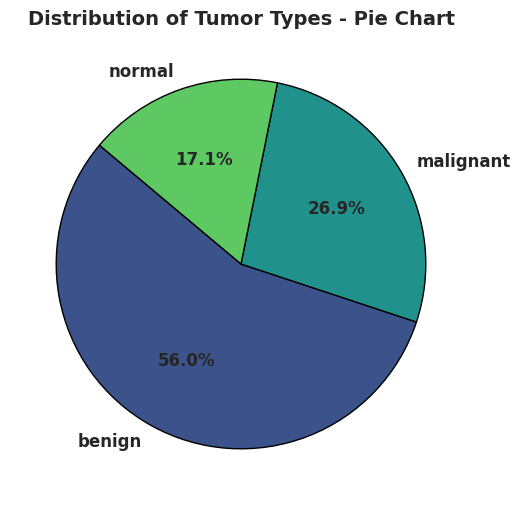

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style("whitegrid")

fig, ax = plt.subplots(figsize=(8, 6))
sns.countplot(data=df, x="Label", palette="viridis", ax=ax)

ax.set_title("Distribution of Tumor Types", fontsize=14, fontweight='bold')
ax.set_xlabel("Tumor Type", fontsize=12)
ax.set_ylabel("Count", fontsize=12)

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=11, color='black',
                xytext=(0, 5), textcoords='offset points')

plt.show()

label_counts = df["Label"].value_counts()

fig, ax = plt.subplots(figsize=(8, 6))
colors = sns.color_palette("viridis", len(label_counts))

ax.pie(label_counts, labels=label_counts.index, autopct='%1.1f%%',
       startangle=140, colors=colors, textprops={'fontsize': 12, 'weight': 'bold'},
       wedgeprops={'edgecolor': 'black', 'linewidth': 1})

ax.set_title("Distribution of Tumor Types - Pie Chart", fontsize=14, fontweight='bold')

plt.show()

#view our data and how its distrbuted and it's looking imbalanced

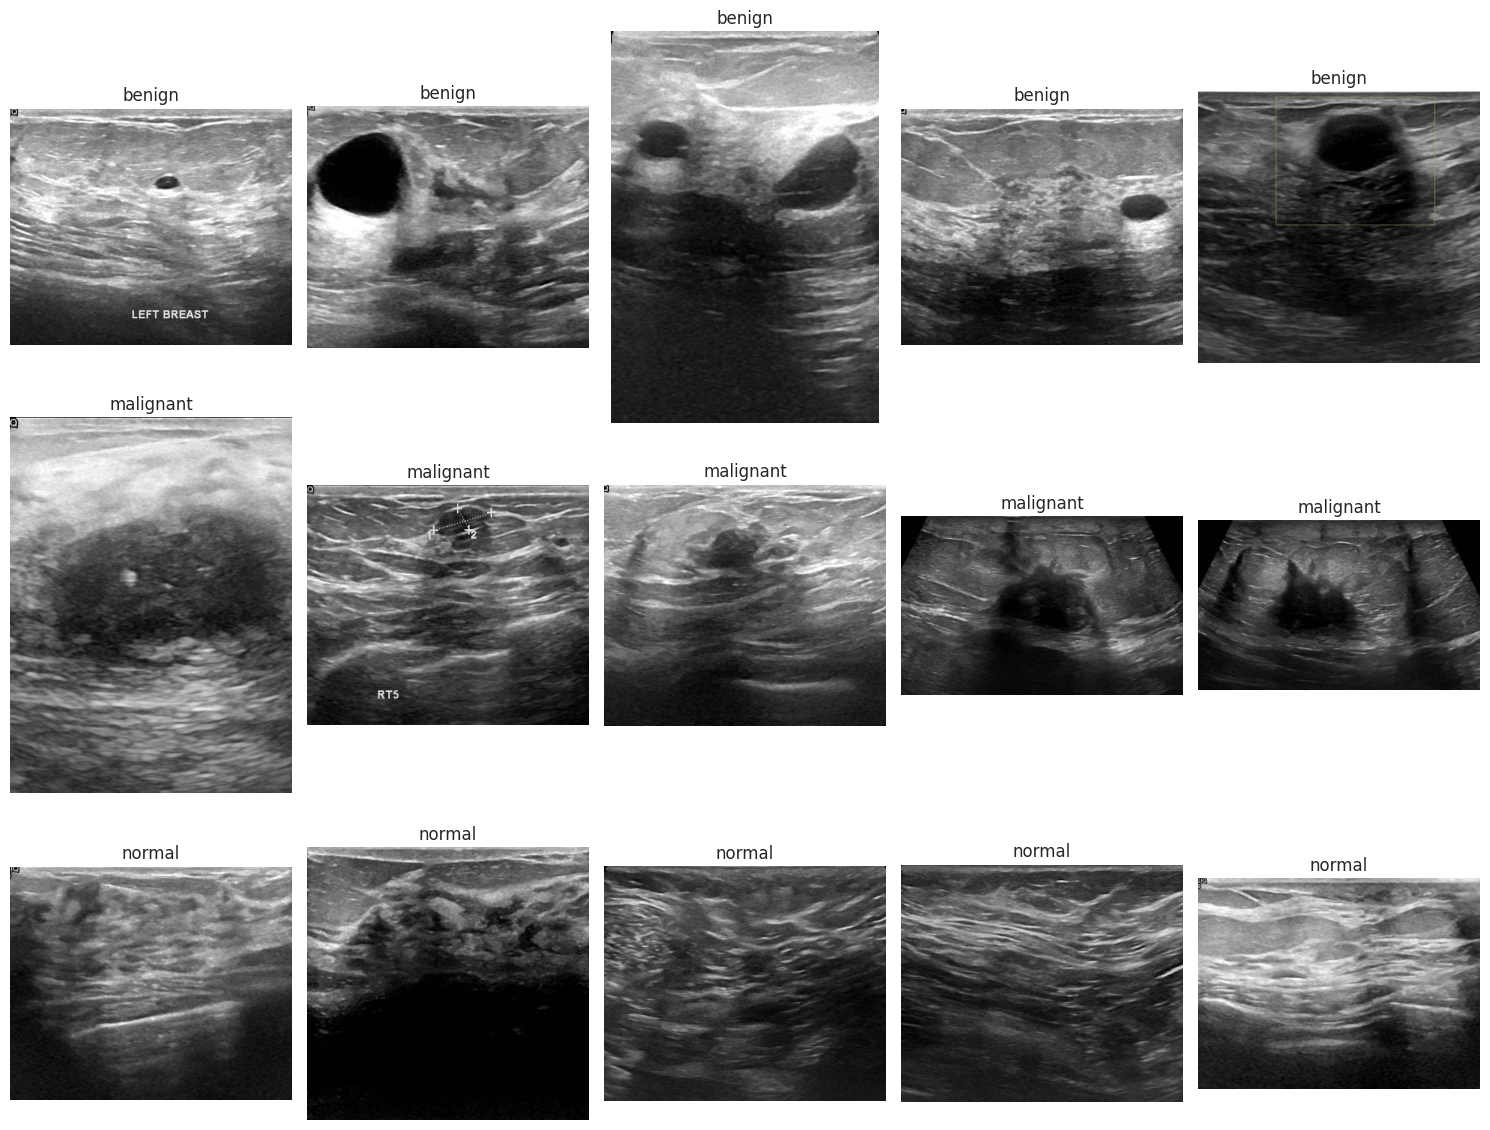

In [19]:
import cv2

num_images = 5
plt.figure(figsize=(15, 12))

for i, category in enumerate(categories):
    category_images = df[df["Label"] == category]["Image_Path"].iloc[:num_images]

    for j, img_path in enumerate(category_images):
        img = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
        plt.subplot(len(categories), num_images, i * num_images + j + 1)
        plt.imshow(img)
        plt.axis("off")
        plt.title(category)

plt.tight_layout()
plt.show()
#This code creates a visual gallery grid of the ultrasound images directly inside your notebook so you can look at them with your own eyes.

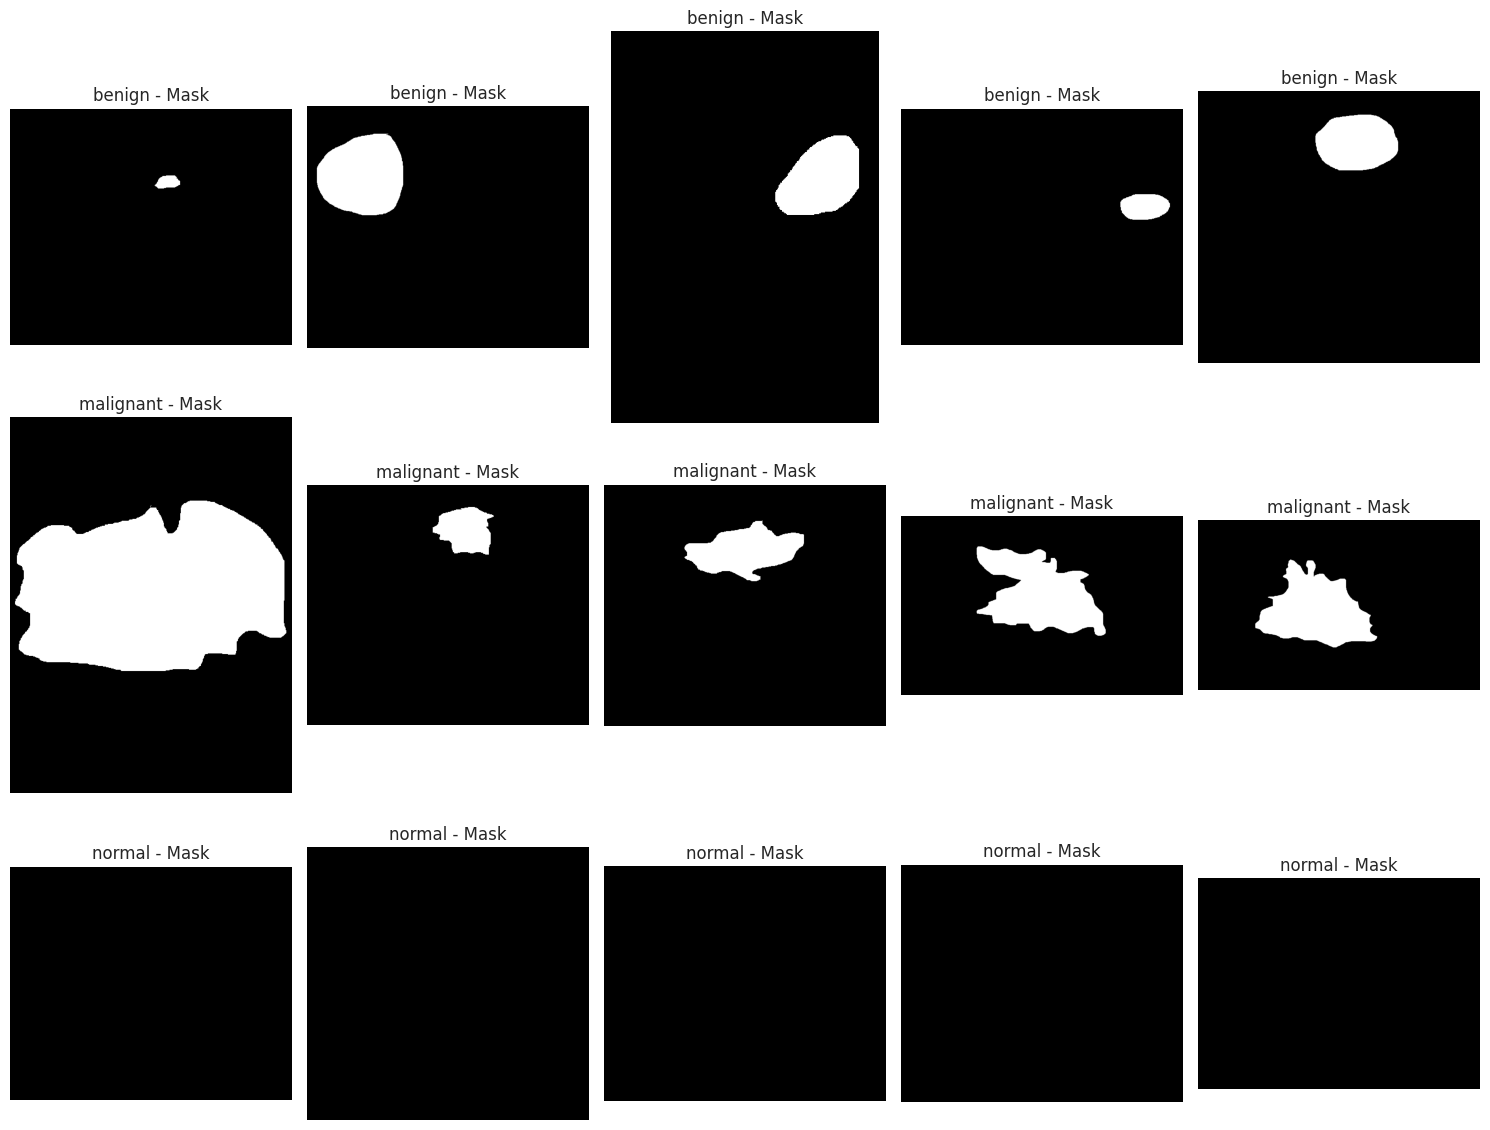

In [20]:
num_images = 5
plt.figure(figsize=(15, 12))

for i, category in enumerate(categories):
    category_masks = df[df["Label"] == category]["Mask_Path"].iloc[:num_images]

    for j, mask_path in enumerate(category_masks):
        mask = cv2.cvtColor(cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE), cv2.COLOR_GRAY2RGB)

        plt.subplot(len(categories), num_images, i * num_images + j + 1)
        plt.imshow(mask)
        plt.axis("off")
        plt.title(f"{category} - Mask")

plt.tight_layout()
plt.show()
# this one here called the mask and its showing us the area of intrest

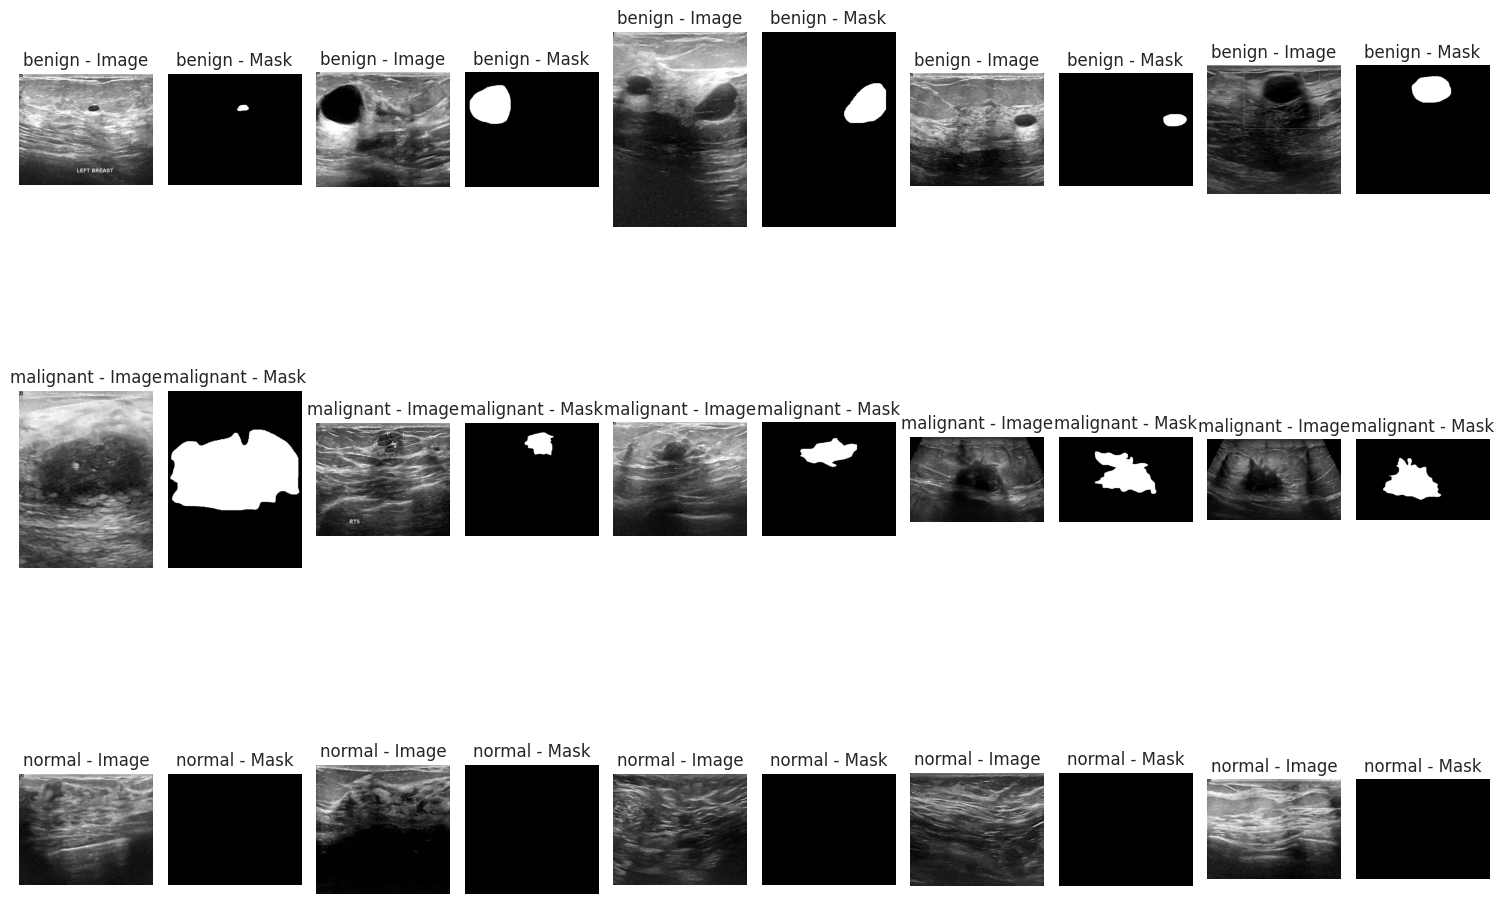

In [21]:
num_images = 5
plt.figure(figsize=(15, 12))

for i, category in enumerate(categories):
    category_images = df[df["Label"] == category]["Image_Path"].iloc[:num_images]
    category_masks = df[df["Label"] == category]["Mask_Path"].iloc[:num_images]

    for j, (img_path, mask_path) in enumerate(zip(category_images, category_masks)):
        img = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
        mask = cv2.cvtColor(cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE), cv2.COLOR_GRAY2RGB)

        plt.subplot(len(categories), num_images * 2, i * num_images * 2 + j * 2 + 1)
        plt.imshow(img)
        plt.axis("off")
        plt.title(f"{category} - Image")

        plt.subplot(len(categories), num_images * 2, i * num_images * 2 + j * 2 + 2)
        plt.imshow(mask)
        plt.axis("off")
        plt.title(f"{category} - Mask")

plt.tight_layout()
plt.show()

# ultrasoundImage - mask (area of intrest)

In [22]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

df['category_encoded'] = label_encoder.fit_transform(df['Label'])
#This code performs Label Encoding, which means it translates text labels into numbers that your computer can actually understand it and use it.

In [23]:
df = df[['Image_Path', 'category_encoded']]
#trimming down your table (DataFrame)

In [24]:
from imblearn.over_sampling import RandomOverSampler

In [25]:
#here we start to make our data balanced
ros = RandomOverSampler(random_state=42)
X_resampled, y_resampled = ros.fit_resample(df[['Image_Path']], df['category_encoded'])


In [26]:
df_resampled = pd.DataFrame(X_resampled, columns=['Image_Path'])
df_resampled['category_encoded'] = y_resampled

In [27]:
print("\nClass distribution after oversampling:")
print(df_resampled['category_encoded'].value_counts())


Class distribution after oversampling:
category_encoded
0    437
1    437
2    437
Name: count, dtype: int64


In [28]:
df_resampled
#just chechking how our data looks right now

,Image_Path,category_encoded
0,breast_ultrasound_data/Dataset_BUSI_with_GT/be...,0
1,breast_ultrasound_data/Dataset_BUSI_with_GT/be...,0
2,breast_ultrasound_data/Dataset_BUSI_with_GT/be...,0
3,breast_ultrasound_data/Dataset_BUSI_with_GT/be...,0
4,breast_ultrasound_data/Dataset_BUSI_with_GT/be...,0
...,...,...
1306,breast_ultrasound_data/Dataset_BUSI_with_GT/no...,2
1307,breast_ultrasound_data/Dataset_BUSI_with_GT/no...,2
1308,breast_ultrasound_data/Dataset_BUSI_with_GT/no...,2
1309,breast_ultrasound_data/Dataset_BUSI_with_GT/no...,2


In [33]:
df_resampled['category_encoded'] = df_resampled['category_encoded'].astype(str)

In [34]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
#Tools to split your data into training/testing sets , prevent overfitting And optmize learning .

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Activation, Dropout, BatchNormalization
from tensorflow.keras import regularizers
#The building blocks for a Neural Network
import warnings
warnings.filterwarnings("ignore")

print ('check')

#calling the necessery libraries for our training

check


In [36]:
train_df_new, temp_df_new = train_test_split(
    df_resampled,
    train_size=0.8,
    shuffle=True,
    random_state=42,
    stratify=df_resampled['category_encoded']
)
# 80% for training of our dataset

valid_df_new, test_df_new = train_test_split(
    temp_df_new,
    test_size=0.5,
    shuffle=True,
    random_state=42,
    stratify=temp_df_new['category_encoded']
)
# 10% for testing its final real-world accuracy.

In [37]:
batch_size = 16 # The AI will look at 16 images at a time, update its learning, and then take the next 16.
img_size = (224, 224) # shape ($224 \times 224$ pixels
channels = 3  # RGB (RED GREEN BLUE)
img_shape = (img_size[0], img_size[1], channels)

tr_gen = ImageDataGenerator(rescale=1./255)  # normalization , now values are between 0-1
ts_gen = ImageDataGenerator(rescale=1./255)

train_gen_new = tr_gen.flow_from_dataframe(
    train_df_new,
    x_col='Image_Path',
    y_col='category_encoded',
    target_size=img_size,
    class_mode='sparse',
    color_mode='rgb',
    shuffle=True, # mix up the order of the training data
    batch_size=batch_size
)

valid_gen_new = ts_gen.flow_from_dataframe(
    valid_df_new,
    x_col='Image_Path',
    y_col='category_encoded',
    target_size=img_size,
    class_mode='sparse',
    color_mode='rgb',
    shuffle=True, # mix up the order of the training data
    batch_size=batch_size
)

test_gen_new = ts_gen.flow_from_dataframe(
    test_df_new,
    x_col='Image_Path',
    y_col='category_encoded',
    target_size=img_size,
    class_mode='sparse',
    color_mode='rgb',
    shuffle=False,
    batch_size=batch_size
)

Found 1048 validated image filenames belonging to 3 classes.
Found 131 validated image filenames belonging to 3 classes.
Found 132 validated image filenames belonging to 3 classes.


In [34]:
import tensorflow as tf

print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

Num GPUs Available:  0


In [40]:
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print("GPU is set for TensorFlow")
    except RuntimeError as e:
        print(e)

In [41]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.optimizers import Adam

#creating our CNN
def create_cnn_model(input_shape, num_classes):
    model = Sequential()

    model.add(Conv2D(8, (3, 3), activation='relu', input_shape=input_shape))   # 8 filters
    model.add(MaxPooling2D(pool_size=(2, 2)))
    # Looks at the raw ultrasound and highlights simple things like bright edges and dark spots.



    model.add(Conv2D(16, (3, 3), activation='relu'))  # 16 filters
    model.add(MaxPooling2D(pool_size=(2, 2)))
    # Looks at those edges and starts matching them together to find simple shapes (like circles or straight lines).

    model.add(Conv2D(32, (3, 3), activation='relu'))  # 32 filters
    model.add(MaxPooling2D(pool_size=(2, 2)))
    # Looks at those shapes and hunts for complex medical features (like a jagged tumor border).

    model.add(Flatten())
    #takes all those clues and lists them out in one long, straight line on a notepad so they are easy to read.

    model.add(Dense(64, activation='relu'))
    # # : A small brain network that reads the clues on the notepad and thinks, "If I see a jagged edge AND a dark shadow, what does that usually mean?"
    model.add(Dense(num_classes, activation='softmax'))
    # The mouth of the detective. It prints out three percentages that add up to 100% (for example: 5% normal, 15% benign, 80% malignant).




    model.compile(
        optimizer=Adam(learning_rate=1e-3),   # The optimization system
        loss='sparse_categorical_crossentropy',# Grading system that calculates exactly how wrong a guess was.
        metrics=['accuracy'] # percentage of images the detective got right.
    )

    return model


input_shape = (224, 224, 3)   # or img_shape if you defined that
num_classes = len(train_df_new['category_encoded'].unique())

model = create_cnn_model(input_shape, num_classes)
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 8)    │           224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 8)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 16)   │         1,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 21632)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     1,384,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,390,739 (5.31 MB)

 Trainable params: 1,390,739 (5.31 MB)

 Non-trainable params: 0 (0.00 B)

In [42]:
#trains your AI model!
history = model.fit(
    train_gen_new,
    validation_data=valid_gen_new,
    epochs=15,
    batch_size=batch_size
)

Epoch 1/15
66/66 ━━━━━━━━━━━━━━━━━━━━ 43s 602ms/step - accuracy: 0.4981 - loss: 1.0194 - val_accuracy: 0.5573 - val_loss: 0.9357
Epoch 2/15
66/66 ━━━━━━━━━━━━━━━━━━━━ 41s 616ms/step - accuracy: 0.7395 - loss: 0.6524 - val_accuracy: 0.7939 - val_loss: 0.5774
Epoch 3/15
66/66 ━━━━━━━━━━━━━━━━━━━━ 41s 611ms/step - accuracy: 0.8406 - loss: 0.4036 - val_accuracy: 0.8321 - val_loss: 0.4332
Epoch 4/15
66/66 ━━━━━━━━━━━━━━━━━━━━ 40s 598ms/step - accuracy: 0.9275 - loss: 0.2186 - val_accuracy: 0.8473 - val_loss: 0.4340
Epoch 5/15
66/66 ━━━━━━━━━━━━━━━━━━━━ 40s 599ms/step - accuracy: 0.9590 - loss: 0.1336 - val_accuracy: 0.9313 - val_loss: 0.3005
Epoch 6/15
66/66 ━━━━━━━━━━━━━━━━━━━━ 41s 616ms/step - accuracy: 0.9761 - loss: 0.0763 - val_accuracy: 0.9313 - val_loss: 0.3487
Epoch 7/15
66/66 ━━━━━━━━━━━━━━━━━━━━ 41s 616ms/step - accuracy: 0.9914 - loss: 0.0405 - val_accuracy: 0.9389 - val_loss: 0.3200
Epoch 8/15
66/66 ━━━━━━━━━━━━━━━━━━━━ 40s 612ms/step - accuracy: 0.9847 - loss: 0.0462 - val_accu

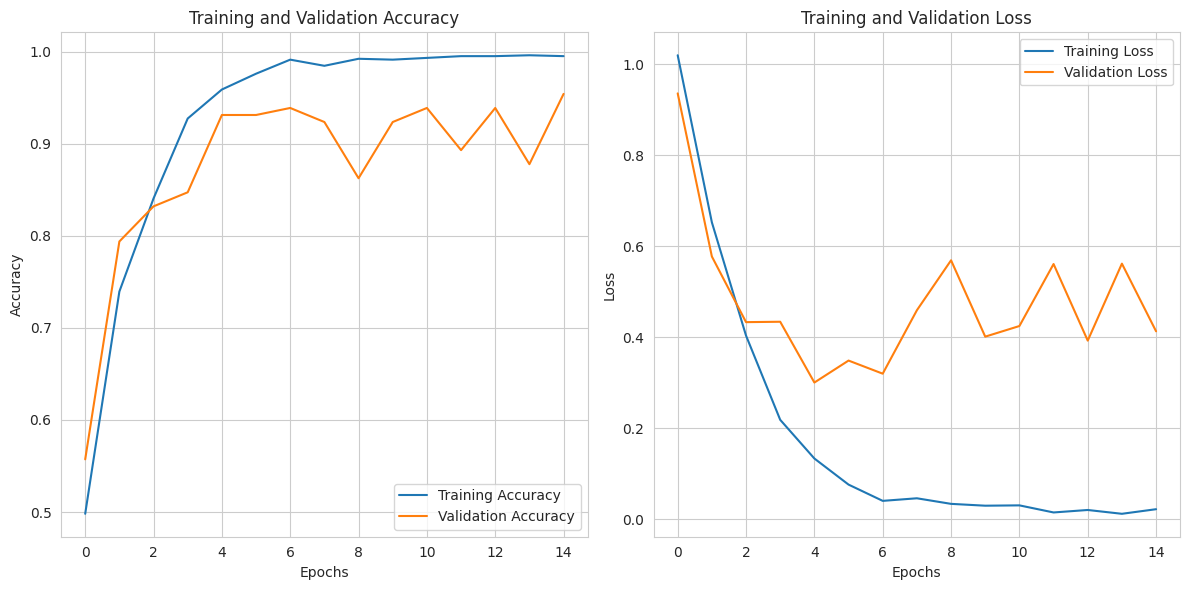

In [43]:
import matplotlib.pyplot as plt

# viewing our results

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 217ms/step


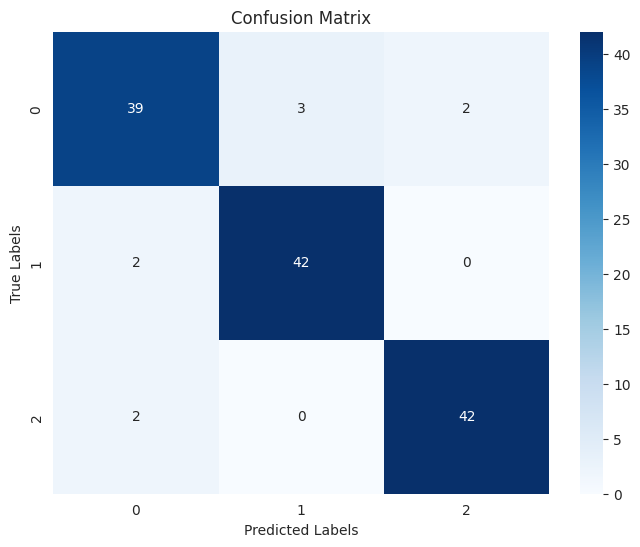

              precision    recall  f1-score   support

           0       0.91      0.89      0.90        44
           1       0.93      0.95      0.94        44
           2       0.95      0.95      0.95        44

    accuracy                           0.93       132
   macro avg       0.93      0.93      0.93       132
weighted avg       0.93      0.93      0.93       132



In [44]:
from sklearn.metrics import confusion_matrix, classification_report

predictions = model.predict(test_gen_new, batch_size=batch_size)
predictions = np.argmax(predictions, axis=1)

true_labels = test_gen_new.classes

conf_matrix = confusion_matrix(true_labels, predictions)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=test_gen_new.class_indices, yticklabels=test_gen_new.class_indices)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

class_report = classification_report(true_labels, predictions, target_names=test_gen_new.class_indices.keys())
print(class_report)

# seeing our training report

In [45]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, Input, Add, Multiply
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import GlobalAveragePooling2D, Reshape, Permute, UpSampling2D

# Function to focus the model on the most important parts of the image
def attention_module(x):
    # Squash the 2D image down to average values for each color/feature channel
    avg_pool = GlobalAveragePooling2D()(x)
    # Reshape it so the computer can process it like a tiny 1x1 image block
    avg_pool = Reshape((1, 1, avg_pool.shape[1]))(avg_pool)

    # Calculate an importance score between 0 and 1 for each feature channel
    attention = Conv2D(filters=x.shape[-1], kernel_size=(1, 1), activation='sigmoid', padding='same')(avg_pool)
    # Stretch the tiny attention scores back out to match the full size of the image
    attention = UpSampling2D(size=(x.shape[1] // 1, x.shape[2] // 1), interpolation='bilinear')(attention)

    # Multiply the original image features by the attention scores to highlight important areas
    x_attention = Multiply()([x, attention])
    return x_attention

# Function to build the entire Neural Network architecture
def create_cnn_model(input_shape, num_classes):
    # Define the shape of the incoming ultrasound image (224x224 pixels, 3 color channels)
    input_layer = Input(shape=input_shape)

    # First Block: Look for 32 basic visual textures and shrink the image size
    x = Conv2D(32, (3, 3), activation='relu', padding='same')(input_layer)
    x = MaxPooling2D(pool_size=(2, 2))(x)
    # Apply the attention highlighter to focus on the tumor region
    x = attention_module(x)

    # Second Block: Look for 64 more complex shapes and shrink the image size again
    x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    x = MaxPooling2D(pool_size=(2, 2))(x)
    # Apply the attention highlighter again
    x = attention_module(x)

    # Third Block: Look for 128 highly detailed patterns and shrink the image size a final time
    x = Conv2D(128, (3, 3), activation='relu', padding='same')(x)
    x = MaxPooling2D(pool_size=(2, 2))(x)
    # Apply the attention highlighter one last time
    x = attention_module(x)

    # Flatten the 2D grid clues into a single long row of numbers
    x = Flatten()(x)
    # High-level thinking layer with 256 artificial neurons to connect the clues
    x = Dense(256, activation='relu')(x)
    # Randomly turn off 50% of the network connections during training to prevent memorization
    x = Dropout(0.5)(x)

    # Output layer: Turn final scores into percentage probabilities for the 3 categories
    x = Dense(num_classes, activation='softmax')(x)

    # Combine the input layer and final layers into a single official model engine
    model = Model(inputs=input_layer, outputs=x)

    # Configure training settings: Adam optimizer, loss function, and tracking accuracy
    model.compile(optimizer=Adam(), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model


# Set up the expected input size for the ultrasound scans
input_shape = (224, 224, 3)
# Count the number of unique target categories (benign, malignant, normal)
num_classes = len(train_df_new['category_encoded'].unique())

# Build the complete attention-based model
model = create_cnn_model(input_shape, num_classes)

# Print out a blueprint list showing the structure and total parameters of the network
model.summary()

Model: "functional_9"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 224, 224,  │        896 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_3     │ (None, 112, 112,  │          0 │ conv2d_3[0][0]    │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 32)        │          0 │ max_pooling2d_3[… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 1, 1, 32)  │          0 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 1, 1, 32)  │      1,056 │ reshape[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d       │ (None, 112, 112,  │          0 │ conv2d_4[0][0]    │
│ (UpSampling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply (Multiply) │ (None, 112, 112,  │          0 │ max_pooling2d_3[… │
│                     │ 32)               │            │ up_sampling2d[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 112, 112,  │     18,496 │ multiply[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_4     │ (None, 56, 56,    │          0 │ conv2d_5[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 64)        │          0 │ max_pooling2d_4[… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_1 (Reshape) │ (None, 1, 1, 64)  │          0 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 1, 1, 64)  │      4,160 │ reshape_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d_1     │ (None, 56, 56,    │          0 │ conv2d_6[0][0]    │
│ (UpSampling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_1          │ (None, 56, 56,    │          0 │ max_pooling2d_4[… │
│ (Multiply)          │ 64)               │            │ up_sampling2d_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 56, 56,    │     73,856 │ multiply_1[0][0]  │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_5     │ (None, 28, 28,    │          0 │ conv2d_7[0][0]    │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 128)       │          0 │ max_pooling2d_5[… │
│ (GlobalAveragePool… │                   │            │                 

 Total params: 25,806,115 (98.44 MB)

 Trainable params: 25,806,115 (98.44 MB)

 Non-trainable params: 0 (0.00 B)

In [46]:
history = model.fit(
    train_gen_new,
    validation_data=valid_gen_new,
    epochs=15,
    batch_size=batch_size
)

Epoch 1/15
66/66 ━━━━━━━━━━━━━━━━━━━━ 169s 3s/step - accuracy: 0.4303 - loss: 1.0622 - val_accuracy: 0.5344 - val_loss: 0.9317
Epoch 2/15
66/66 ━━━━━━━━━━━━━━━━━━━━ 162s 2s/step - accuracy: 0.6031 - loss: 0.8581 - val_accuracy: 0.6870 - val_loss: 0.7663
Epoch 3/15
66/66 ━━━━━━━━━━━━━━━━━━━━ 160s 2s/step - accuracy: 0.6765 - loss: 0.7332 - val_accuracy: 0.7786 - val_loss: 0.6596
Epoch 4/15
66/66 ━━━━━━━━━━━━━━━━━━━━ 160s 2s/step - accuracy: 0.7595 - loss: 0.5951 - val_accuracy: 0.8168 - val_loss: 0.5963
Epoch 5/15
66/66 ━━━━━━━━━━━━━━━━━━━━ 161s 2s/step - accuracy: 0.8149 - loss: 0.4824 - val_accuracy: 0.7863 - val_loss: 0.5760
Epoch 6/15
66/66 ━━━━━━━━━━━━━━━━━━━━ 160s 2s/step - accuracy: 0.8578 - loss: 0.3861 - val_accuracy: 0.8702 - val_loss: 0.4592
Epoch 7/15
66/66 ━━━━━━━━━━━━━━━━━━━━ 160s 2s/step - accuracy: 0.8969 - loss: 0.3055 - val_accuracy: 0.8931 - val_loss: 0.3957
Epoch 8/15
66/66 ━━━━━━━━━━━━━━━━━━━━ 202s 2s/step - accuracy: 0.9256 - loss: 0.2078 - val_accuracy: 0.8779 - v

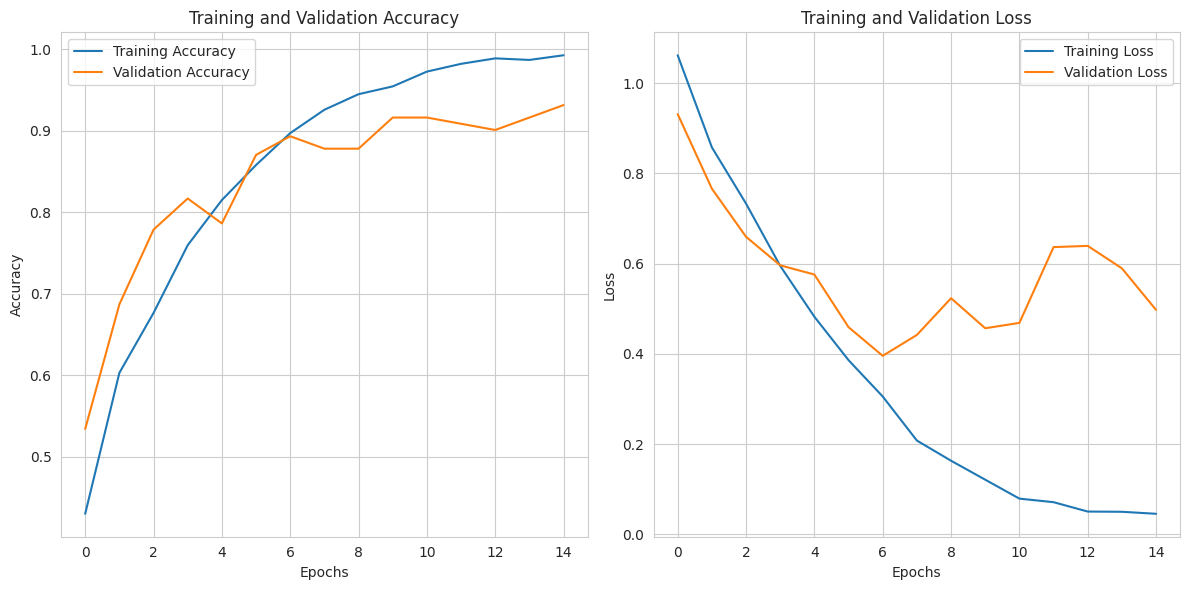

In [47]:
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()


9/9 ━━━━━━━━━━━━━━━━━━━━ 6s 569ms/step


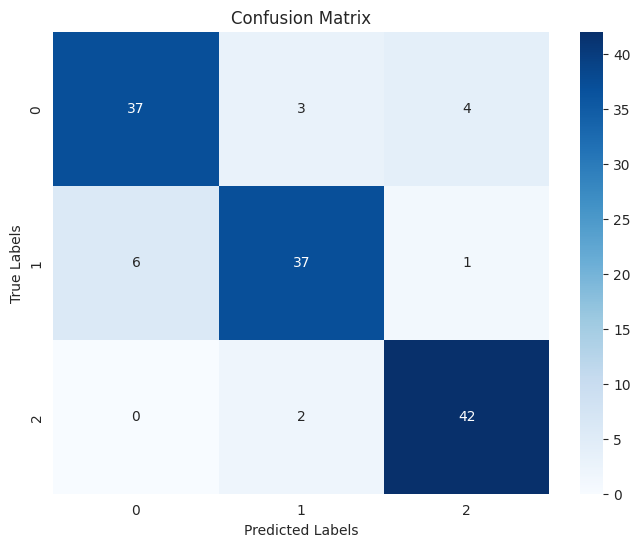

              precision    recall  f1-score   support

           0       0.86      0.84      0.85        44
           1       0.88      0.84      0.86        44
           2       0.89      0.95      0.92        44

    accuracy                           0.88       132
   macro avg       0.88      0.88      0.88       132
weighted avg       0.88      0.88      0.88       132



In [49]:
predictions = model.predict(test_gen_new, batch_size=batch_size)
predictions = np.argmax(predictions, axis=1)

true_labels = test_gen_new.classes

conf_matrix = confusion_matrix(true_labels, predictions)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=test_gen_new.class_indices, yticklabels=test_gen_new.class_indices)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

class_report = classification_report(true_labels, predictions, target_names=test_gen_new.class_indices.keys())
print(class_report)

In [1]:
# Save the model
model.save("my_model.keras")

NameError: name 'model' is not defined

In [51]:
# Load the model later
from tensorflow import keras
model = keras.models.load_model("my_model.keras")